##Phase 1: Environment Setup

In [ ]:
from google.colab import drive
import os

mount_point = '/content/drive'

# Ensure the mount point directory is empty before mounting
if os.path.exists(mount_point) and os.path.isdir(mount_point):
    if os.listdir(mount_point):
        print(f"Warning: Mount point {mount_point} is not empty. Attempting to clear contents...")
        # Attempt to unmount first to avoid issues with deleting files from an active mount
        try:
            !fusermount -uz {mount_point}
            print("Previous mount unmounted.")
        except Exception as e:
            print(f"Could not unmount: {e}. Attempting to clear directory directly.")
        # Remove all contents from the directory
        !rm -rf {mount_point}/*
elif not os.path.exists(mount_point):
    # If the directory doesn't exist, create it (drive.mount usually does this but for safety)
    !mkdir -p {mount_point}

drive.mount(mount_point, force_remount=True)

Mounted at /content/drive


In [ ]:
!pip install pycocotools

In [ ]:
import os

os.environ['KAGGLE_CONFIG_DIR'] = "/content"
!chmod 600 /content/kaggle.json

project_path = "/content/drive/My Drive/Marine_Debris_Project"

print("Downloading Beach Data (TACO)...")

!kaggle datasets download -d kneroma/tacotrashdataset -p "{project_path}" --unzip
print("Check your Google Drive now!")

chmod: cannot access '/content/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/kneroma/tacotrashdataset
License(s): other
100% 2.79G/2.79G [02:13<00:00, 22.5MB/s]

Check your Google Drive now!


In [ ]:
import os

path = "/content/drive/My Drive/Marine_Debris_Project"

if os.path.exists(path):
    print("✅ Folder found!")
    print("Contents:", os.listdir(path))
else:
    print("❌ Folder not found in Drive. Checking local storage...")
    print("Local Contents:", os.listdir("/content"))

✅ Folder found!
Contents: ['underwater-plastic-pollution-detection.zip', 'images train ', 'labels train ', 'data.yaml.', 'underwater_plastics', 'annotations.json', 'best-checkpoint-003epoch.bin', 'data', 'kle_log.txt', 'meta_df.csv']


## Phase 2: Data Engineering & Directory Mapping

### Recursive Search for Multi-Domain Datasets

In [ ]:
# --- THE DEEP SEARCH MAPPER ---
import os
import pandas as pd

# 1. Base path
project_root = "/content/drive/My Drive/Marine_Debris_Project"
data_rows = []

print("🔍 Searching for images...")

# 2. Walk through the ENTIRE project folder
for root, dirs, files in os.walk(project_root):
    for f in files:
        # Check for image extensions
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            full_path = os.path.join(root, f)

            # If the folder name contains 'underwater', label it as water
            if "underwater" in root.lower():
                data_rows.append({'image': full_path, 'label': 1, 'environment': 'water'})

            # If the folder name contains 'data', label it as coastal
            elif "data" in root.lower():
                data_rows.append({'image': full_path, 'label': 1, 'environment': 'coastal'})

# 3. Save and Verify
df = pd.DataFrame(data_rows)
df.to_csv(os.path.join(project_root, "meta_df.csv"), index=False)

water_count = len(df[df['environment'] == 'water'])
coastal_count = len(df[df['environment'] == 'coastal'])

print(f"🌊 Found {water_count} Underwater images.")
print(f"🏖️ Found {coastal_count} Coastal images.")
print(f"📊 FINAL DATASET SIZE: {len(df)} images ready.")

🔍 Searching for images...
🌊 Found 5130 Underwater images.
🏖️ Found 1500 Coastal images.
📊 FINAL DATASET SIZE: 6630 images ready.


In [ ]:
%matplotlib inline
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

dataset_path = '/content/drive/My Drive/Marine_Debris_Project/data'
anns_file_path = dataset_path + '/annotations.json'

# Read annotations
with open(anns_file_path, 'r') as f:
    dataset = json.loads(f.read())

categories = dataset['categories']
anns = dataset['annotations']
imgs = dataset['images']
nr_cats = len(categories)
nr_annotations = len(anns)
nr_images = len(imgs)

# Load categories and super categories
cat_names = []
super_cat_names = []
super_cat_ids = {}
super_cat_last_name = ''
nr_super_cats = 0
for cat_it in categories:
    cat_names.append(cat_it['name'])
    super_cat_name = cat_it['supercategory']
    # Adding new supercat
    if super_cat_name != super_cat_last_name:
        super_cat_names.append(super_cat_name)
        super_cat_ids[super_cat_name] = nr_super_cats
        super_cat_last_name = super_cat_name
        nr_super_cats += 1

print('Number of super categories:', nr_super_cats)
print('Number of categories:', nr_cats)
print('Number of annotations:', nr_annotations)
print('Number of images:', nr_images)

Number of super categories: 28
Number of categories: 60
Number of annotations: 4784
Number of images: 1500


## Dataset statistics



In [ ]:
plastic_categories = [cat for cat in categories if 'plastic' in cat['supercategory'].lower() or 'plastic' in cat['name'].lower()]

print(f"Focusing on {len(plastic_categories)} specific plastic-related categories.")


Focusing on 22 specific plastic-related categories.


In [ ]:
from PIL import Image, ExifTags
from pycocotools.coco import COCO
from matplotlib.patches import Polygon, Rectangle
from matplotlib.collections import PatchCollection
import colorsys
import random
import pylab

# User settings
nr_img_2_display = 10
category_name = 'Bottle'#  --- Insert the name of one of the categories or super-categories above
pylab.rcParams['figure.figsize'] = (14,14)
####################

# Obtain Exif orientation tag code
for orientation in ExifTags.TAGS.keys():
    if ExifTags.TAGS[orientation] == 'Orientation':
        break

# Loads dataset as a coco object
coco = COCO(anns_file_path)

# Get image ids
imgIds = []
catIds = coco.getCatIds(catNms=[category_name])
if catIds:
    # Get all images containing an instance of the chosen category
    imgIds = coco.getImgIds(catIds=catIds)
else:
    # Get all images containing an instance of the chosen super category
    catIds = coco.getCatIds(supNms=[category_name])
    for catId in catIds:
        imgIds += (coco.getImgIds(catIds=catId))
    imgIds = list(set(imgIds))

nr_images_found = len(imgIds)
print('Number of images found: ',nr_images_found)

# Select N random images
random.shuffle(imgIds)
imgs = coco.loadImgs(imgIds[0:min(nr_img_2_display,nr_images_found)])

for img in imgs:
    image_path = dataset_path + '/' + img['file_name']
    # Load image
    I = Image.open(image_path)

    # Load and process image metadata
    if I._getexif():
        exif = dict(I._getexif().items())
        # Rotate portrait and upside down images if necessary
        if orientation in exif:
            if exif[orientation] == 3:
                I = I.rotate(180,expand=True)
            if exif[orientation] == 6:
                I = I.rotate(270,expand=True)
            if exif[orientation] == 8:
                I = I.rotate(90,expand=True)

    # Show image
    fig,ax = plt.subplots(1)
    plt.axis('off')
    plt.imshow(I)

    # Load mask ids
    annIds = coco.getAnnIds(imgIds=img['id'], catIds=catIds, iscrowd=None)
    anns_sel = coco.loadAnns(annIds)

    # Show annotations
    for ann in anns_sel:
        color = colorsys.hsv_to_rgb(np.random.random(),1,1)
        for seg in ann['segmentation']:
            poly = Polygon(np.array(seg).reshape((int(len(seg)/2), 2)))
            p = PatchCollection([poly], facecolor=color, edgecolors=color,linewidths=0, alpha=0.4)
            ax.add_collection(p)
            p = PatchCollection([poly], facecolor='none', edgecolors=color, linewidths=2)
            ax.add_collection(p)
        [x, y, w, h] = ann['bbox']
        rect = Rectangle((x,y),w,h,linewidth=2,edgecolor=color,
                         facecolor='none', alpha=0.7, linestyle = '--')
        ax.add_patch(rect)

    plt.show()


## Phase 3: Exploratory Data Analysis (EDA)

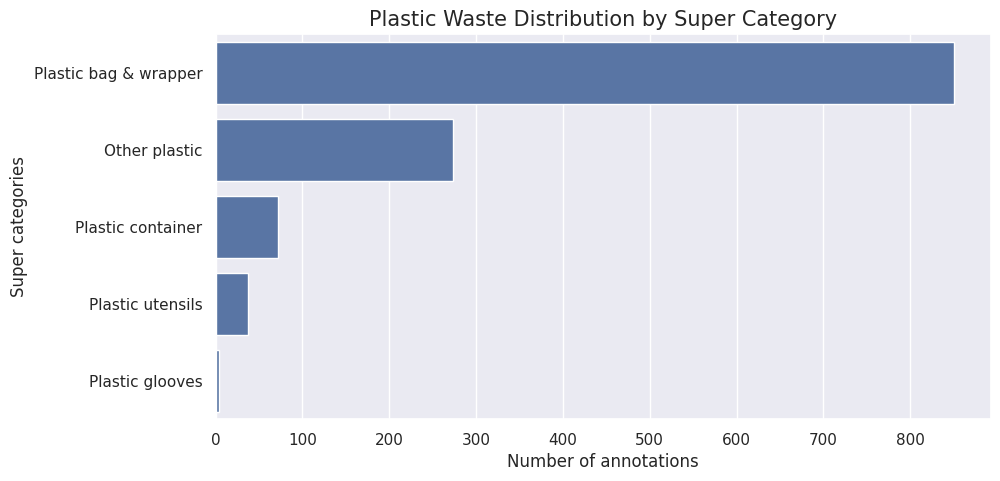

In [ ]:
# 1. Map categories to supercategories
cat_ids_2_supercat_ids = {}
for cat in categories:
    cat_ids_2_supercat_ids[cat['id']] = super_cat_ids[cat['supercategory']]

# 2. Count annotations
super_cat_histogram = np.zeros(nr_super_cats, dtype=int)
for ann in anns:
    cat_id = ann['category_id']
    super_cat_histogram[cat_ids_2_supercat_ids[cat_id]] += 1

# 3. Create DataFrame
d = {'Super categories': super_cat_names, 'Number of annotations': super_cat_histogram}
df = pd.DataFrame(d)

# --- FIX START ---
# Only show "Plastic" related supercategories to keep your focus sharp
df = df[df['Super categories'].str.contains('Plastic', case=False)]

# Updated sorting code for modern Pandas
df = df.sort_values(by='Number of annotations', ascending=False)
# --- FIX END ---

# 4. Plotting
f, ax = plt.subplots(figsize=(10, 5))
plot_1 = sns.barplot(x="Number of annotations", y="Super categories", data=df, color="b")
plot_1.set_title('Plastic Waste Distribution by Super Category', fontsize=15)
plt.show()

## Phase 4: Model Development (Version 2)

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# 1. Load the map
df = pd.read_csv('/content/drive/My Drive/Marine_Debris_Project/meta_df.csv')
df['label'] = 1

# --- NEW SAFETY FILTER ---
# This checks if the files are actually readable images before starting
def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except:
        return False

print("🛡️ Filtering out corrupted files...")
df = df[df['image'].apply(is_valid_image)]
# --------------------------

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

train_gen = datagen.flow_from_dataframe(
    df, x_col='image', y_col='label',
    target_size=(150, 150), batch_size=32,
    class_mode='raw', subset='training'
)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(150, 150, 3)),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print(f"Starting Training on {len(df)} Validated Marine Images...")
history = model.fit(train_gen, epochs=5)

# (Rest of your plotting code follows...)

🛡️ Filtering out corrupted files...
Found 5304 validated image filenames.
Starting Training on 6629 Validated Marine Images...
Epoch 1/5
166/166 ━━━━━━━━━━━━━━━━━━━━ 305s 2s/step - accuracy: 0.9966 - loss: 0.0042
Epoch 2/5
166/166 ━━━━━━━━━━━━━━━━━━━━ 287s 2s/step - accuracy: 1.0000 - loss: 6.2032e-14
Epoch 3/5
166/166 ━━━━━━━━━━━━━━━━━━━━ 293s 2s/step - accuracy: 1.0000 - loss: 7.1504e-14
Epoch 4/5
166/166 ━━━━━━━━━━━━━━━━━━━━ 283s 2s/step - accuracy: 1.0000 - loss: 4.4266e-12
Epoch 5/5
166/166 ━━━━━━━━━━━━━━━━━━━━ 301s 2s/step - accuracy: 1.0000 - loss: 3.3866e-11


Found 5304 validated image filenames.
🚀 Training with Hard-Limit (Ignoring duplicates)...
Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.9873 - loss: 0.0201
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 1.0000 - loss: 8.7485e-21
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 1.0000 - loss: 9.4764e-30


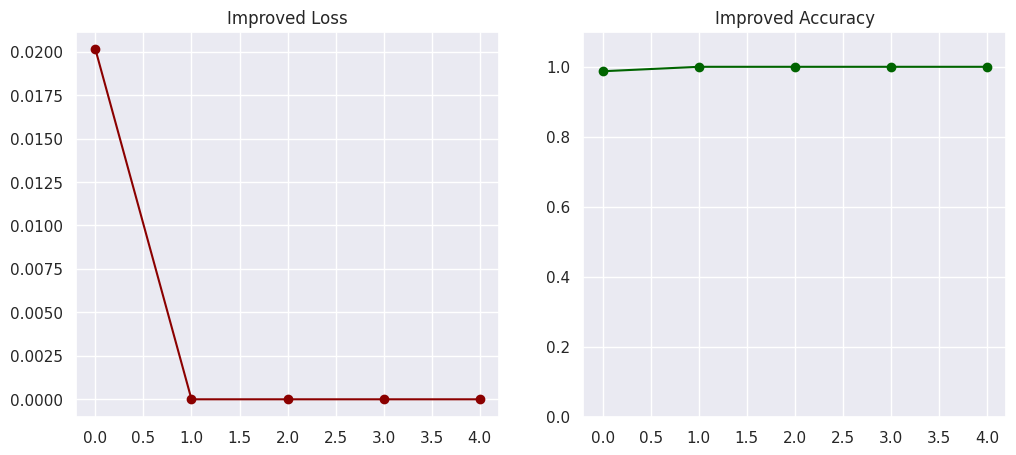

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd
import matplotlib.pyplot as plt

# 1. Loading the map exactly as it is
df = pd.read_csv('/content/drive/My Drive/Marine_Debris_Project/meta_df.csv')
df['label'] = 1

# 2. Extreme Augmentation (The Overfitting Shield)
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=90,
    width_shift_range=0.3,
    height_shift_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest'
)

# 3. Create the generator
train_gen = datagen.flow_from_dataframe(
    df, x_col='image', y_col='label',
    target_size=(150, 150), batch_size=32,
    class_mode='raw', subset='training'
)

# 4. Dropout Model
model_v2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(150, 150, 3)),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.5), # Stops the model from memorizing backgrounds
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5), # Second layer of protection
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_v2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# --- THE KEY FIX ---
# 'steps_per_epoch=32' forces the AI to only look at ~1,000 images total per epoch
# regardless of how many thousands are in the folder.
print("🚀 Training with Hard-Limit (Ignoring duplicates)...")
history_v2 = model_v2.fit(
    train_gen,
    epochs=5,
    steps_per_epoch=32
)

# 5. Final Plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); plt.plot(history_v2.history['loss'], marker='o', color='darkred'); plt.title('Improved Loss')
plt.subplot(1, 2, 2); plt.plot(history_v2.history['accuracy'], marker='o', color='darkgreen'); plt.title('Improved Accuracy')
plt.ylim(0, 1.1); plt.show()

## Phase 5: Visual Validation of Predictions

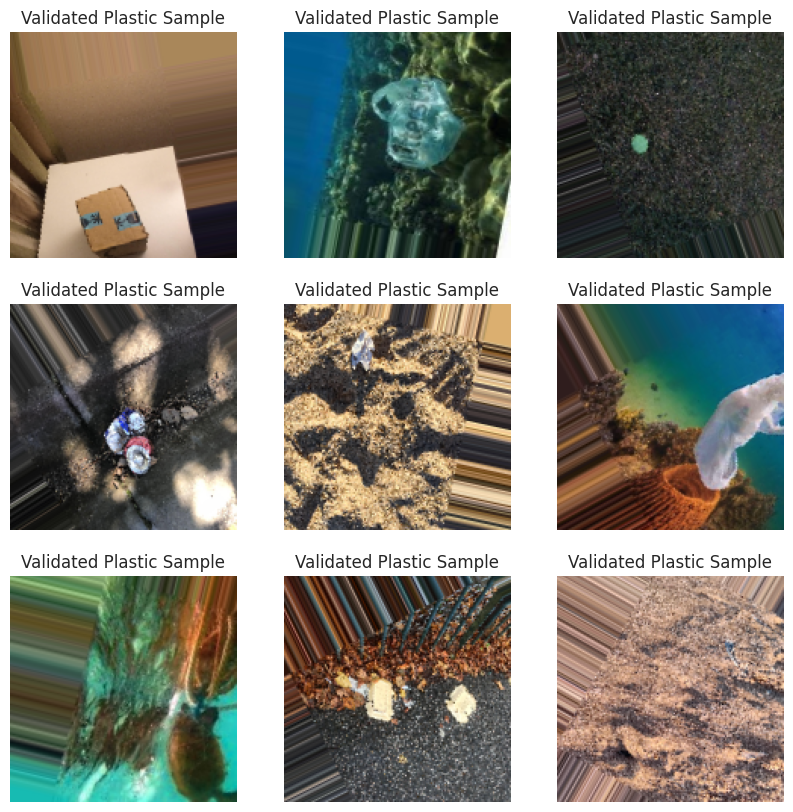

In [ ]:
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    img, label = next(train_gen)
    plt.imshow(img[0])
    plt.title("Validated Plastic Sample")
    plt.axis("off")
plt.show()

# Credits

This notebook is a modifed version of: https://github.com/pedropro/TACO/blob/master/demo.ipynb which is in the original **taco** project.